# Importing Libraries for CNN Model Training and Evaluation

This section imports the necessary Python libraries for building, training, and evaluating a Convolutional Neural Network (CNN) model.


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

# Loading and Preprocessing data

In [2]:
# Load & Preprocess Data to 128
def load_data(target_size=(128, 128)):
    train_images = np.load('data/train_images.npy')
    train_labels = np.load('data/train_labels.npy')
    
    # Resize images
    train_images = tf.image.resize(train_images, target_size).numpy()
    
    # One-hot encode
    train_labels = tf.keras.utils.to_categorical(train_labels, 5)
    return train_images, train_labels


In [3]:
train_images, train_labels = load_data()

2025-03-07 09:44:42.156561: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-03-07 09:44:42.161229: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7637041152 exceeds 10% of free system memory.


# Building a Lightweight Custom CNN Model

This section defines a function to create a lightweight Convolutional Neural Network (CNN) model using TensorFlow Keras. 
Implementing a Separable Conv2D that breaks down convolution into depthwise and pointwise to reduce the number or parameters while also preventing overfitting. This reduces complexity and improves efficiency


In [11]:
# Lightweight Custom CNN
from tensorflow.keras.regularizers import l2
def build_lightweight_model():
    model = Sequential([
        # data_augmentation,  # Uncomment if using data augmentation
        SeparableConv2D(64, (3,3), activation='relu', 
                        depthwise_regularizer=l2(0.001), 
                        pointwise_regularizer=l2(0.001), 
                        input_shape=(64,64,3)),
        MaxPooling2D((2,2)),
        BatchNormalization(),
        Dropout(0.25),

        SeparableConv2D(128, (3,3), activation='relu', 
                        depthwise_regularizer=l2(0.001), 
                        pointwise_regularizer=l2(0.001)),
        MaxPooling2D((2,2)),
        GlobalAveragePooling2D(),
        Dropout(0.5),

        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),  # L2 for dense layer
        Dense(5, activation='softmax')
    ])
    return model

In [12]:
# Train with Optimizations
model = build_lightweight_model() 

# Computing Class Weights for Imbalanced Datasets

Class weights are implemented to ensure that the model learns effectively from all classes


In [13]:
# Class weights
class_weights = class_weight.compute_class_weight('balanced', 
                                                 classes=np.unique(np.argmax(train_labels, axis=1)),
                                                 y=np.argmax(train_labels, axis=1))
class_weights = dict(enumerate(class_weights))


# Implementing Early Stopping, Learning Rate Scheduling, and Model Compilation

This section details the setup for training a TensorFlow Keras model, including early stopping, learning rate scheduling, and model compilation.


In [14]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam

lr_schedule = ExponentialDecay(initial_learning_rate=0.001, decay_steps=10000, decay_rate=0.9)
optimizer = Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Training the Model

In [15]:
history = model.fit(
    train_images, train_labels,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 246ms/step - accuracy: 0.5215 - loss: 1.1639 - val_accuracy: 0.9161 - val_loss: 0.4481
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 80s 239ms/step - accuracy: 0.9479 - loss: 0.3208 - val_accuracy: 0.9774 - val_loss: 0.2278
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 81s 237ms/step - accuracy: 0.9546 - loss: 0.2692 - val_accuracy: 0.9825 - val_loss: 0.1893
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 59s 243ms/step - accuracy: 0.9688 - loss: 0.2161 - val_accuracy: 0.9866 - val_loss: 0.1567
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 60s 248ms/step - accuracy: 0.9731 - loss: 0.1847 - val_accuracy: 0.9882 - val_loss: 0.1421
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 59s 243ms/step - accuracy: 0.9800 - loss: 0.1570 - val_accuracy: 0.9871 - val_loss: 0.1408
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 60s 247ms/step - accuracy: 0.9802 - loss: 0.1473 - val_accuracy: 0.9866 - val_loss: 0.1186
Epoch 8/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 60s 248ms/step - accuracy: 0.9832 - loss: 0

# Saving the model

In [16]:
import pickle
with open('models/final_team1model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Freeing Memory

In [17]:
import gc
# Free Memory
del train_images, train_labels
gc.collect()

903

# Loading and Preprocessing testing data

In [18]:
test_images = np.load('data/test_images.npy')
test_labels = np.load('data/test_labels.npy')
# One-hot encode
test_labels = tf.keras.utils.to_categorical(test_labels, 5)
def load_test_data(X, target_size=(128, 128)):
    # Resize images
    test_images = tf.image.resize(X, target_size).numpy()
    
    
    return test_images


# Loading the Model into memory

In [20]:
# Load Optimized Model
with open('models/final_team1model.pkl', 'rb') as file:
    cnn_model = pickle.load(file)

# Evaluating the CNN Pipeline

This section evaluates the performance of the trained Convolutional Neural Network (CNN) pipeline using the test dataset.


102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step

### Evaluation Metrics ###

Evaluation Time:       16.34 seconds (The time it took for the pipeline to preprocess data and make predictions.)
Peak Memory Usage:     12504.59 MB (The maximum memory used during evaluation.)
Average CPU Usage:     504.20 % (The % shows how much of one CPU core was used during the evaluation.)
Algorithm code size:         0.25 MB (The size of the trained model and preprocessing function.)
Accuracy:              0.997 (The percentage of correctly classified samples.)
F1 Score:              0.997 (A balance of precision and recall, useful for imbalanced datasets.)

### Confusion Matrix ###



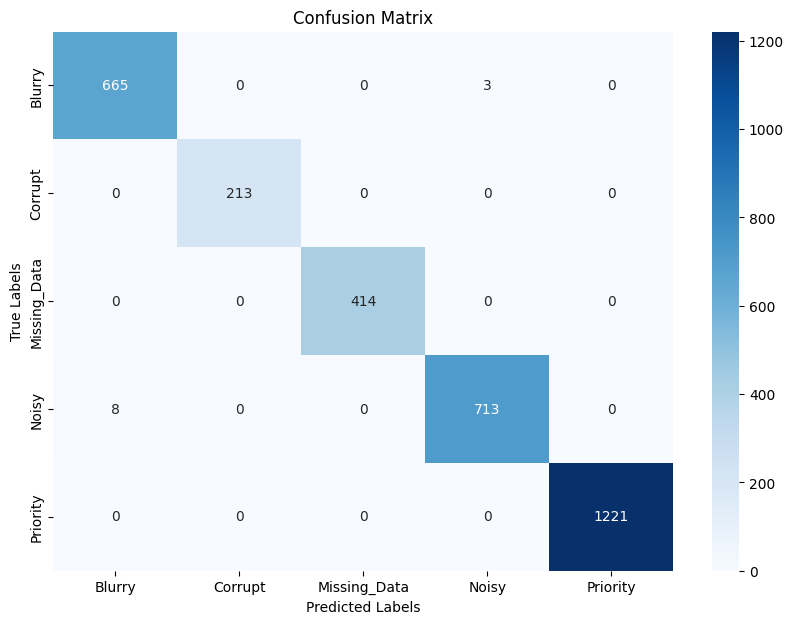

In [21]:
# Evaluate Pipeline
from source.evaluate import evaluate_pipeline
metrics = evaluate_pipeline(cnn_model, test_images, test_labels,load_test_data )

In [22]:
import gc
# Free Memory
del test_images, test_labels
gc.collect()

0

In [23]:
from tensorflow.keras import backend as K
# Clear previous models from memory
K.clear_session()
gc.collect()

0